In [1]:
import numpy as np
import pandas as pd
import json
from scipy.io import arff

from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd

In [2]:
import sys
sys.path.append("..")

In [3]:
from src.data.formatting import resample_data_set
from src.conformal_risk_control.fnr import compute_prediction_set
from src.model_selection.fnr_oracle import compute_oracle_prediction_set
from src.model_selection.fnr_upper import compute_upper_prediction_set
from src.model_selection.fnr_split import select_predictor_index

In [4]:
def reader(path_params):
    with open(path_params, "r") as file:
        params = json.load(file)
    print(params)
    return params

In [8]:
arff_file = arff.loadarff("../datasets/yeast.arff")
data_frame = pd.DataFrame(arff_file[0])
inputs_ = (data_frame[data_frame.columns[:103]]).to_numpy()
outputs_ = np.int64((data_frame[data_frame.columns[103:]]).to_numpy() == b"TRUE")

In [9]:
params_global = reader("params/experiment_2.json")

{'data': {'cal_size': 0.3, 'proper_cal_size': 0.5}, 'predictor': {'n_estimators_min': 10, 'n_estimators_max': 100, 'criterion': ['gini', 'entropy'], 'lam_numbers': ['14', '22', '32', '38']}, 'risk': {'control_level': 0.25}}


In [10]:
complete_n_estimators_grid = np.arange(params_global["predictor"]["n_estimators_min"], params_global["predictor"]["n_estimators_max"]+1)
np.random.shuffle(complete_n_estimators_grid)
n_estimators_grid = complete_n_estimators_grid[: 11]
print(n_estimators_grid)

[68 78 61 53 74 87 46 76 64 51 84]


In [11]:
parameter_grid =  np.array(
    [
        {"n_estimators": n_estimators, "criterion": criterion}
        for n_estimators in n_estimators_grid
        for criterion in params_global["predictor"]["criterion"]
    ], dtype = object
)
print(parameter_grid)

[{'n_estimators': np.int64(68), 'criterion': 'gini'}
 {'n_estimators': np.int64(68), 'criterion': 'entropy'}
 {'n_estimators': np.int64(78), 'criterion': 'gini'}
 {'n_estimators': np.int64(78), 'criterion': 'entropy'}
 {'n_estimators': np.int64(61), 'criterion': 'gini'}
 {'n_estimators': np.int64(61), 'criterion': 'entropy'}
 {'n_estimators': np.int64(53), 'criterion': 'gini'}
 {'n_estimators': np.int64(53), 'criterion': 'entropy'}
 {'n_estimators': np.int64(74), 'criterion': 'gini'}
 {'n_estimators': np.int64(74), 'criterion': 'entropy'}
 {'n_estimators': np.int64(87), 'criterion': 'gini'}
 {'n_estimators': np.int64(87), 'criterion': 'entropy'}
 {'n_estimators': np.int64(46), 'criterion': 'gini'}
 {'n_estimators': np.int64(46), 'criterion': 'entropy'}
 {'n_estimators': np.int64(76), 'criterion': 'gini'}
 {'n_estimators': np.int64(76), 'criterion': 'entropy'}
 {'n_estimators': np.int64(64), 'criterion': 'gini'}
 {'n_estimators': np.int64(64), 'criterion': 'entropy'}
 {'n_estimators': n

In [12]:
predictors = [
    OneVsRestClassifier(RandomForestClassifier(**parameter)) for parameter in parameter_grid
]

In [13]:
rep_number = 100

In [14]:
results = {
    "size":{
        "Oracle":[],
        "Upper":[],
        "Split":[],
        "Output":[],
    }, "FNR":{
        "Oracle":[],
        "Upper":[],
        "Split":[],
    }
}

In [15]:
for rep_index in tqdm(range(rep_number)):
    (
        (scaled_inputs_train, outputs_train),
        (scaled_inputs_calibration, outputs_calibration),
        (
            scaled_inputs_selection,
            scaled_inputs_proper_cal,
            outputs_selection,
            outputs_proper_cal,
        ),
        (scaled_input_test, output_test),
    ) = resample_data_set(inputs_, outputs_, params_global["data"]["cal_size"], params_global["data"]["proper_cal_size"])


    for predictor in predictors:
        predictor.fit(scaled_inputs_train, outputs_train)


    probas_calibration_per_predictor = [
        predictor.predict_proba(scaled_inputs_calibration) for predictor in predictors
    ]
    proba_test_per_predictor = [
        predictor.predict_proba(scaled_input_test) for predictor in predictors
    ]
    oracle_prediction_set = compute_oracle_prediction_set(
        outputs_calibration,
        probas_calibration_per_predictor,
        output_test,
        proba_test_per_predictor,
        params_global["risk"]["control_level"],
    )

    
    upper_prediction_set = compute_upper_prediction_set(
        outputs_calibration,
        probas_calibration_per_predictor,
        proba_test_per_predictor,
        params_global["risk"]["control_level"],
    )



    probas_selection_per_predictor = [
        predictor.predict_proba(scaled_inputs_selection) for predictor in predictors
    ]
    split_predictor_index = select_predictor_index(
        outputs_selection, probas_selection_per_predictor, params_global["risk"]["control_level"]
    )
    split_prediction_set = compute_prediction_set(
        predictors[split_predictor_index],
        scaled_inputs_proper_cal,
        outputs_proper_cal,
        scaled_input_test,
        params_global["risk"]["control_level"]
    )

    oracle_fnr = (
        np.logical_and(output_test, np.logical_not(oracle_prediction_set)).sum(axis=1)
        / output_test.sum(axis=1)
    ).item()
    upper_fnr = (
        np.logical_and(output_test, np.logical_not(upper_prediction_set)).sum(axis=1)
        / output_test.sum(axis=1)
    ).item()
    split_fnr = (
        np.logical_and(output_test, np.logical_not(split_prediction_set)).sum(axis=1)
        / output_test.sum(axis=1)
    ).item()
    
    results["FNR"]["Oracle"].append(oracle_fnr)
    results["FNR"]["Upper"].append(upper_fnr)
    results["FNR"]["Split"].append(split_fnr)

    results["size"]["Oracle"].append(oracle_prediction_set.sum())
    results["size"]["Upper"].append(upper_prediction_set.sum())
    results["size"]["Split"].append(split_prediction_set.sum())
    results["size"]["Output"].append(output_test.sum())

    
    print("Average oracle prediction-set size: {}".format(np.mean(results["size"]["Oracle"])))
    print("Average output size: {}".format(np.mean(results["size"]["Output"])))
    print("Average split prediction-set size: {}".format(np.mean(results["size"]["Split"])))
    print("Average upper prediction-set size: {}".format(np.mean(results["size"]["Upper"])))


  1%|          | 1/100 [04:38<7:40:05, 278.84s/it]

Average oracle prediction-set size: 7.0
Average output size: 4.0
Average split prediction-set size: 7.0
Average upper prediction-set size: 7.0


  2%|▏         | 2/100 [09:12<7:30:35, 275.87s/it]

Average oracle prediction-set size: 7.0
Average output size: 5.0
Average split prediction-set size: 6.5
Average upper prediction-set size: 7.0


  3%|▎         | 3/100 [13:45<7:23:35, 274.39s/it]

...

Average oracle prediction-set size: 5.4
Average output size: 4.066666666666666
Average split prediction-set size: 5.133333333333334
Average upper prediction-set size: 5.466666666666667


 16%|█▌        | 16/100 [1:12:59<6:24:17, 274.50s/it]

Average oracle prediction-set size: 5.3125
Average output size: 4.0625
Average split prediction-set size: 5.0625
Average upper prediction-set size: 5.375


 16%|█▌        | 16/100 [1:17:30<6:46:55, 290.66s/it]


ValueError: zero-size array to reduction operation minimum which has no identity

In [170]:
print("Average oracle prediction-set size: {}".format(np.mean(results["size"]["Oracle"])))
print("Average output size: {}".format(np.mean(results["size"]["Output"])))
print("Average split prediction-set size: {}".format(np.mean(results["size"]["Split"])))
print("Average upper prediction-set size: {}".format(np.mean(results["size"]["Upper"])))

Average oracle prediction-set size: 5.31
Average output size: 3.66
Average split prediction-set size: 5.52
Average upper prediction-set size: 6.49


In [171]:
df_volume = pd.DataFrame.from_dict(
    results["size"]
)

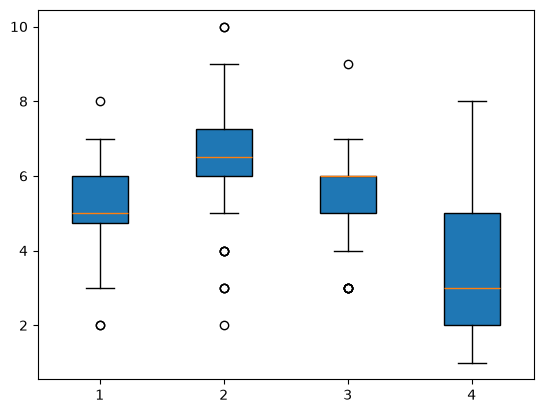

In [172]:
fig, ax = plt.subplots()
box = ax.boxplot(df_volume, patch_artist=True)

In [173]:
print("Average oracle prediction-set FNR: {}".format(np.mean(results["FNR"]["Oracle"])))
print("Average split prediction-set FNR: {}".format(np.mean(results["FNR"]["Split"])))
print("Average upper prediction-set FNR: {}".format(np.mean(results["FNR"]["Upper"])))

Average oracle prediction-set FNR: 0.23871428571428574
Average split prediction-set FNR: 0.28064285714285714
Average upper prediction-set FNR: 0.17135714285714287


In [174]:
df_fnr = pd.DataFrame.from_dict(
    results["FNR"]
)

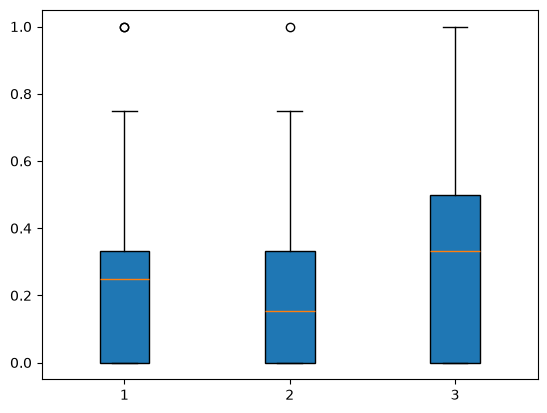

In [175]:
fig, ax = plt.subplots()
box = ax.boxplot(df_fnr, patch_artist=True)